# Анализ лояльности пользователей Яндекс Афиши


# Contents

[Введение](#Введение)
<br>[Цели и задачи проекта](#goals)
1. [Загрузка и предобработка данных](#1-bullet)
    <br>1.1. [Подключение к базе данных и выполнение SQL-запроса](#1.1-bullet)
    <br>1.2. [Описание выгруженных данных](#1.2-bullet)
    <br>1.3. [Оценка корректности выгрузки и объёма данных](#1.3-bullet)
    <br>1.4. [Промежуточный вывод по шагу 1](#1.4-bullet)
    
2. [Предобработка данных](#2-bullet)
    <br>[2.1. Приведение выручки к единой валюте (тенге → рубли)](#2.1-bullet)
    <br>[2.2. Обработка пропусков и оптимизация типов](#2.2-bullet)
    <br>[2.3. Фильтрация данных по 99-му перцентилю](#2.3-bullet)
    <br>[2.4. Промежуточный вывод по шагу 2](#2.4-bullet)

3. [Создание профиля пользователя](#3-bullet)
    <br>[3.1. Агрегация признаков и бинарные метки (is_two, is_five)](#3.1-bullet)
    <br>[3.2. Анализ аномалий и фильтрация (total_orders)](#3.2-bullet)

4. [Исследовательский анализ данных (EDA)](#4-bullet)
    <br>[4.1. Анализ признаков первого заказа и возвратов](#4.1-bullet)
    <br>[4.2. Анализ выручки и количества билетов](#4.2-bullet)
    <br>[4.3. Анализ временных характеристик (день недели, интервалы)](#4.3-bullet)
    <br>[4.4. Корреляционный анализ (phi_k)](#4.4-bullet)
5. [Общий вывод и рекомендации](#5-bullet)
6. [Финализация проекта и публикация в Git](#section_6)

# Введение
В данном проекте мы проводим исследовательский анализ данных о заказах пользователей Яндекс Афиши. Цель — понять, какие характеристики пользователей и их первых заказов связаны с вероятностью возврата на платформу и совершения повторных покупок.

 

# Ключевые задачи:

1. Загрузить и предобработать данные из базы данных
2. Построить профили пользователей с агрегированными признаками
3. Исследовать влияние различных факторов на удержание клиентов
4. Сформулировать рекомендации для отдела маркетинга


<a id='1-bullet'></a>
#  Загрузка данных и их предобработка


## Подключение к базе данных с помощью Python


Прежде чем использовать библиотеку, нужно её установить. Запустим команду для установки SQLAlchemy:

In [1]:
!pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


Кроме того, нужно установить модуль psycopg2. Он также необходим для подключения к базе данных:

In [2]:
!pip install psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable


Устанавливаем библиотеку phik

In [3]:
!pip install phik -U

Defaulting to user installation because normal site-packages is not writeable


Импортируем остальные библиотеки, с которыми будем работать в проекте.

In [4]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from datetime import datetime
import warnings
import phik
from phik.report import plot_correlation_matrix
warnings.filterwarnings('ignore')

In [5]:
# Настройка отображения графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

Для подключения к базе данных понадобится:
- имя пользователя базы данных и пароль;
- адрес сервера базы данных, включая порт;
- название базы данных.
Эти данные удобно записать в объект, чтобы потом их было легко поправить. 

In [6]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

После того как данные для авторизации записаны в объект `db_config`, нужно передать функции `create_engine()` строку для соединения с базой данных, сформированную с помощью метода `.format():`

In [7]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

Чтобы создать соединение, строку с данными для подключения передаём функции `create_engine()`:

In [8]:
engine = create_engine(connection_string)

<a id='1.1-bullet'></a>
### Извлечение результатов SQL-запроса

Запрос можно записать в переменную `query`  — так его удобнее редактировать. 

In [9]:
query = '''
WITH filtered_purchases AS (
  SELECT 
    order_id,
    user_id,
    created_dt_msk,
    created_ts_msk,
    event_id,
    cinema_circuit,
    age_limit,
    currency_code,
    device_type_canonical,
    revenue,
    service_name,
    tickets_count,
    total
  FROM afisha.purchases
  WHERE device_type_canonical IN ('mobile', 'desktop')
),

with_prev_order AS (
  SELECT 
    *,
    LAG(created_dt_msk::date) OVER (
      PARTITION BY user_id 
      ORDER BY created_dt_msk, order_id
    ) AS prev_order_date
  FROM filtered_purchases
)

SELECT 
  wpo.user_id,
  wpo.device_type_canonical,
  wpo.order_id,
  wpo.created_dt_msk AS order_dt,
  wpo.created_ts_msk AS order_ts,
  wpo.currency_code,
  wpo.revenue,
  wpo.tickets_count,
  (wpo.created_dt_msk::date - wpo.prev_order_date) AS days_since_prev,
  wpo.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  wpo.service_name,
  r.region_name,
  c.city_name
FROM with_prev_order wpo
INNER JOIN afisha.events e ON wpo.event_id = e.event_id
INNER JOIN afisha.city c ON e.city_id = c.city_id
INNER JOIN afisha.regions r ON c.region_id = r.region_id
WHERE e.event_type_main != 'фильм'
ORDER BY wpo.user_id;
'''

Результат выдачи SQL-запроса запишем в датафрейм с помощью метода `pd.read_sql_query()`:

In [10]:
df = pd.read_sql_query(query, con=engine)

Используем контекстный менеджер для автоматического закрытия соединения: 

In [11]:
# открываем и автоматически закрываем соединение
with engine.connect() as connection:
    df = pd.read_sql(query, con=connection)

Сдлаем на всякий случай копию данных для дальнейшей работы.

In [12]:
# Создаем полную копию данных
df_copy = df.copy()

[Назад к содержанию](#Contents)

<a id='1.2-bullet'></a>
### Описание данных

Датафрейм содержит:
- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---

[Назад к содержанию](#Contents)

---
<a id='1.3-bullet'></a>
**Задача 1.2:** Изучим общую информацию о выгруженных данных. Оценим корректность выгрузки и объём полученных данных.

Предположим, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируем основную информацию о данных в кратком промежуточном выводе.

---

Получаем общую инфромацию о выгруженных данных. Оценим корректность выгрузки и объём полученных данных.

Выводим первые 5 строк датафрейма.

In [13]:
display(df.head())

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


Проверям информацию о типах данных

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268696 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

<a id='1.4-bullet'></a>
**Промежуточный вывод:**

**1. Оценка корректности выгрузки и объёма данных:**

- **Объём:** В датасете `290 611 строк` и `15 столбцов`. Это достаточно представительная выборка для анализа. Память `(33.3+ MB)`расходуется оптимально для такого количества записей.

- **Целостность:** Почти все столбцы заполнены полностью `(290 611 non-null)`.
- **Пропуски:** Единственный столбец с пропусками — `days_since_prev` (около `7.5%` пустых значений). Это логично: для первой покупки пользователя «количества дней с предыдущей» просто не существует. Выгрузка выглядит корректной.

**2. Предложения по предобработке:**

**Корректировка типов данных:**

**Изменение типов данных:**

- `days_since_prev` — имеет тип `float64` из-за пропусков. Если заменить `NaN` на `0`, можно перевести в `int` для экономии памяти.

**Оптимизация категорий:**

- Столбцы `device_type_canonical`, `currency_code` и `event_type_main` содержат повторяющиеся текстовые значения. Перевод в тип `category` ускорит вычисления в разы.
- Столбцы `event_id (max=592325)`, `order_id (max=8653108)`, `revenue(max=81174.54)`, `days_since_prev (max=148.0)` можно привести `float32` и `int32`, `tickets_count(max=57)` к `int8`.

**Обработка пропусков:**

В `days_since_prev` пропуски `(NaN)` можно заменить на `0` или специальное значение-заглушку, чтобы иметь возможность перевести столбец из `float64` в `int64.`, а затем в `int32`.

**Проверка дубликатов:**

Необходимо проверить данные на полные дубликаты строк, а также на уникальность `order_id` (не должно быть повторов одного и того же заказа).

Также числовые столбцы требуют проверки на выбросы, а данные о выручке сервиса нужно привести к единой валюте — российскому рублю.

[Назад к содержанию](#Contents)

---
<a id='2-bullet'></a>
##  Предобработка данных



---
<a id='2.1-bullet'></a>
**Задача 2.1**
Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведём выручку к единой валюте — российскому рублю.

Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Результаты преобразования сохраним в новый столбец `revenue_rub`.

---


Загружаем датафрейм с курсом тенге.

In [15]:
# Загрузка курса тенге
tenge_rates = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
tenge_rates['data'] = pd.to_datetime(tenge_rates['data'])
display(f"Загружено {len(tenge_rates)} записей с курсами тенге")
display(tenge_rates.head())

'Загружено 357 записей с курсами тенге'

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Проверяем соотвествие типов данных в двух датафреймах. 

In [16]:
print(f"Тип в основном DF: {df['order_dt'].dtype}")
print(f"Тип в таблице курсов: {tenge_rates['data'].dtype}")


Тип в основном DF: datetime64[ns]
Тип в таблице курсов: datetime64[ns]


Проверим, есть ли все необходимые даты в датафрейме с курсом тенге.

In [17]:
# Создаем списки уникальных дат
sales_dates = set(df['order_dt'].dt.date)
rate_dates = set(tenge_rates['data'].dt.date)

# Находим разницу (даты, для которых нет курса)
missing_dates = sales_dates - rate_dates

if not missing_dates:
    print("Все даты совпадают! Курсы есть для каждого дня.")
else:
    print(f"Внимание! Нет курсов для {len(missing_dates)} дат.")
    print(f"Примеры пропущенных дат: {list(missing_dates)[:5]}")


Все даты совпадают! Курсы есть для каждого дня.


In [18]:
# 1. Присоединяем только нужную колонку курса по датам
df = df.merge(tenge_rates[['data', 'curs']], left_on='order_dt', right_on='data', how='left')

# 2. Пересчитываем выручку там, где валюта — тенге
df.loc[df['currency_code'] == 'KZT', 'revenue'] *= df['curs'] / 100

# 3. Убираем лишние колонки, которые притянулись при объединении
df = df.drop(columns=['data', 'curs']).rename(columns={'revenue': 'revenue_rub'})


[Назад к содержанию](#Contents)

---
<a id='2.2-bullet'></a>
**Задача 2.2:**

- Проверим данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуем типы данных в некоторых столбцах, если это необходимо.
- Изучим значения в ключевых столбцах. Обработаем ошибки, если обнаружим их.
    - Проверим, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведём нормализацию данных, если это необходимо.
    - Проверим распределение численных данных и наличие в них выбросов. Для этого используем статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверим данные в этих столбцах.
        
      
После предобработки проверим, были ли отфильтрованы данные. Сформулируем промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Проверим получившийся датафрейм на пропуски:

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue_rub            290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268696 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Пропуски остались только в колонке `days_since_prev`. Заполняем пропуски: если дней с прошлого заказа нет, значит это первый заказ (ставим 0). Сразу проверим пропуски.

In [20]:
df['days_since_prev'] = df['days_since_prev'].fillna(0)
display(df.isnull().sum())

user_id                  0
device_type_canonical    0
order_id                 0
order_dt                 0
order_ts                 0
currency_code            0
revenue_rub              0
tickets_count            0
days_since_prev          0
event_id                 0
event_name               0
event_type_main          0
service_name             0
region_name              0
city_name                0
dtype: int64

**Преобразование типов данных**
Оптимизируем память для числовых столбцов:

In [21]:
# Оптимизация числовых столбцов
df['tickets_count'] = df['tickets_count'].astype('int16')
df['revenue_rub'] = df['revenue_rub'].astype('float32')
df['event_id'] = df['event_id'].astype('int32')
df['order_id'] = df['order_id'].astype('int32')

Сдедаем то же самое для категориальных данных:

In [22]:
# Категориальные столбцы
cat_cols = ['device_type_canonical', 'currency_code', 'service_name', 
            'event_type_main', 'region_name', 'city_name']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  category      
 6   revenue_rub            290611 non-null  float32       
 7   tickets_count          290611 non-null  int16         
 8   days_since_prev        290611 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  cate

Проверим категориальные данные на наоичие неявных дубликатов:

In [24]:
# Список колонок для проверки
cols_to_check = ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'region_name', 'city_name']

found_any = False

for col in cols_to_check:
    # 1. Создаем временную очищенную версию (без пробелов и в нижнем регистре)
    temp_clean = df[col].astype(str).str.strip().str.lower()
    
    # 2. Ищем, где одному очищенному значению соответствует несколько разных исходных
    duplicates_info = df.groupby(temp_clean)[col].nunique()
    dirty_variants = duplicates_info[duplicates_info > 1].index
    
    if not dirty_variants.empty:
        found_any = True
        display(Markdown(f"###Неявные дубликаты в колонке: `{col}`"))
        
        # Показываем, какие именно варианты написания существуют и сколько их
        report = (
            df[temp_clean.isin(dirty_variants)]
            .groupby([temp_clean, col])
            .size()
            .reset_index(name='Кол-во строк')
        )
        display(report)

if not found_any:
    display("Неявных дубликатов в выбранных колонках не найдено.")


'Неявных дубликатов в выбранных колонках не найдено.'

Проведём анализ выбросов в `revenue_rub`:

In [25]:
df['revenue_rub'].describe()

count    290611.000000
mean        625.584351
std        1227.627808
min         -90.760002
25%         116.849998
50%         356.010010
75%         810.130005
max       81174.539062
Name: revenue_rub, dtype: float64

Среднее почти в два раза больше медианы, а максимум в сотни раз превышает типичные значения. Это говорит о том, что в данных есть «длинный хвост» из очень дорогих заказов (выбросов), которые сильно завышают среднее значение.

<a id='2.3-bullet'></a>
Используем фильтрацию по 99-му перцентилю, которая помогажет избавиться от экстремальных выбросов.

In [26]:
# 1. Сохраняем количество строк ДО фильтрации
initial_count = len(df)

# Находим значение 99-го перцентиля
threshold = df['revenue_rub'].quantile(0.99)

# Оставляем только те строки, где выручка меньше или равна этому порогу
# Заодно убираем отрицательные значения (меньше 0)
# Перезаписываем сам df, оставляя нужные значения
df = df[(df['revenue_rub'] <= threshold) & (df['revenue_rub'] >= 0)]

display(f"Порог 99-го перцентиля: {threshold}")
display(f"Удалено строк: {initial_count - len(df)}")


'Порог 99-го перцентиля: 4003.1329589844513'

'Удалено строк: 3288'

Сделаем визуализацию по отфильтрованным значениям `revenue_rub`:

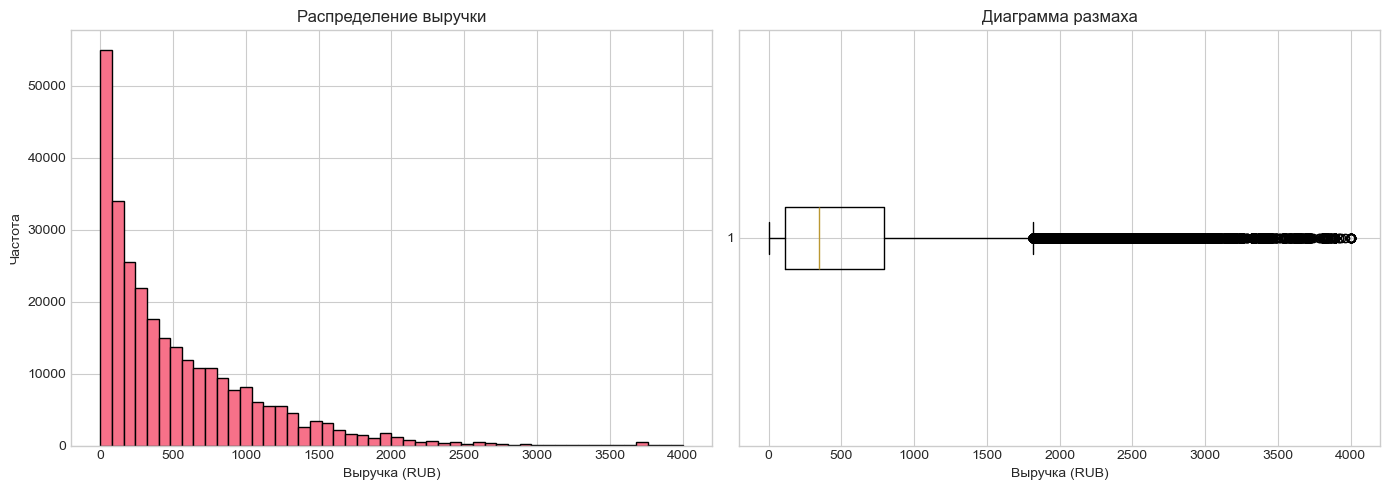

In [27]:
# Визуализация распределения выручки
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['revenue_rub'], bins=50, edgecolor='black')
axes[0].set_xlabel('Выручка (RUB)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение выручки')

axes[1].boxplot(df['revenue_rub'].dropna(), vert=False)
axes[1].set_xlabel('Выручка (RUB)')
axes[1].set_title('Диаграмма размаха')

plt.tight_layout()
plt.show()

**1. Распределение выручки:**
- Форма:  распределение с правым хвостом. Огромное количество мелких заказов (до 500 рублей) и постепенное снижение частоты к более дорогим покупкам.
- Типичный чек: Основная масса транзакций сосредоточена в диапазоне от 0 до ~800 рублей.

**2. Диаграмма размаха:**
- Медиана: Рыжая линия находится примерно на уровне 350-400 рублей (это «типичный» заказ).
- Межквартильный размах (ящик): 50% всех заказов лежат в диапазоне примерно от 100 до 800 рублей.
- Выбросы (черная полоса справа): Несмотря на отсечку 1%, у вас все еще много значений, которые статистически считаются «выбросами» (точки за правым «усом»). Но это нормально для e-commerce — это просто дорогие покупки, а не ошибки данных.

Проведём анализ выбросов в `tickets_count`:

In [28]:
df['tickets_count'].describe()

count    287323.000000
mean          2.750490
std           1.171444
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

Медиана `(3.0)` и Среднее `(2.75)` очень близки. Это хороший знак — значит, данные распределены довольно равномерно, без таких диких перекосов, как в выручке.
Аномалия: Максимум — `57` билетов.
Для обычного пользователя это очень много. Возможно, это групповая закупка, корпоративный заказ или ошибка.

Также отфильтруем `tickets_count` по 99-му перцентилю:

In [29]:
# Запоминаем количество строк до очистки
initial_count = len(df)
# Находим значение 99-го перцентиля
threshold_ticket = df['tickets_count'].quantile(0.99)

# 2. Перезаписываем df, оставляя значения до порога
# Это обновит исходный объект
df = df[(df['tickets_count'] <= threshold_ticket)]

display(f"Порог 99-го перцентиля: {threshold_ticket}")
display(f"Удалено строк: {initial_count - len(df)}")


'Порог 99-го перцентиля: 6.0'

'Удалено строк: 187'

Сделаем визуализацию распределения:

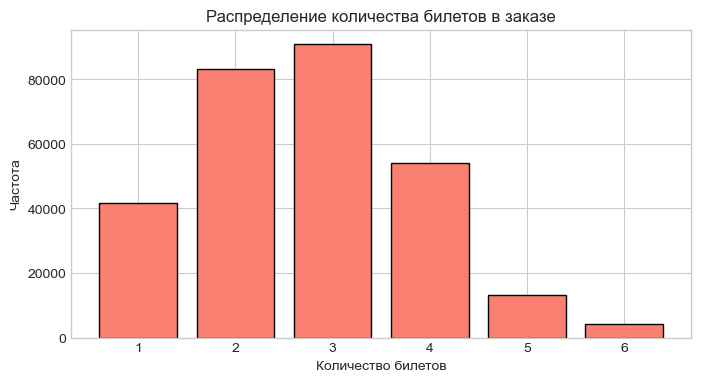

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(df['tickets_count'], 
         bins=np.arange(1, 8) - 0.5, # центрируем столбики
         edgecolor='black', 
         color='salmon', 
         rwidth=0.8) 
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.title('Распределение количества билетов в заказе')
plt.show()

- Самый популярный заказ: Это 3 билета (мода распределения).
- Второе место: Заказы по 2 билета.
- Редкие случаи: Покупка 5 и 6 билетов встречается значительно реже, хотя это всё ещё норма для обычных пользователей (не перекупов и не корпоратов).

<a id='2.4-bullet'></a>
**Промежуточный вывод 2.2:**

- Пропуски корректны: только в days_since_prev
- Типы данных оптимизированы для экономии памяти
- Выбросы по `revenue_rub` и `tickets_count` отфильтрованы по 99-му перцентилю, построены графики распределения
- Новый столбец `revenue_rub` содержит выручку в рублях

[Назад к содержанию](#Contents)

---
<a id='3-bullet'></a>
## Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому построим агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---
<a id='3.1-bullet'></a>
**Задача 3.1.** Построим профиль пользователя.

---


Перед тем как строить профиль, отсортируем данные по времени совершения заказа.

In [ ]:
# Сортировка по пользователю и времени
df = df.sort_values(['user_id', 'order_ts'], ignore_index=True)

Для каждого пользователя найдём:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами

После этого добавим два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.


In [ ]:
# Функция создания профиля
def create_user_profile(df):
    """Создаёт агрегированный профиль для каждого пользователя"""
    
    # Базовые агрегации
    profile = df.groupby('user_id').agg(
        first_order_dt=('order_dt', 'min'),
        last_order_dt=('order_dt', 'max'),
        total_orders=('order_id', 'count'),
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets_count=('tickets_count', 'mean'),
        avg_days_between=('days_since_prev', 'mean')
    ).reset_index()
    
    # Данные о первом заказе
    first_orders = df.groupby('user_id').first().reset_index()
    first_features = first_orders[[
        'user_id', 'device_type_canonical', 'region_name', 
        'service_name', 'event_type_main'
    ]].copy()
    first_features.columns = [
        'user_id', 'first_device', 'first_region', 
        'first_service', 'first_event_type'
    ]
    
    # Объединение
    profile = profile.merge(first_features, on='user_id', how='left')
    
    # Бинарные признаки
    profile['is_two'] = (profile['total_orders'] >= 2).astype(int)
    profile['is_five'] = (profile['total_orders'] >= 5).astype(int)
    
    # Лайфтайм в днях
    profile['lifetime_days'] = (profile['last_order_dt'] - profile['first_order_dt']).dt.days
    
    return profile

# Создание профиля
user_profile = create_user_profile(df)

display(f"Профили созданы для {len(user_profile)} пользователей")
display(user_profile.head())

[Назад к содержанию](#Contents)

---
<a id='3.2-bullet'></a>
**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

---

Используя данные о профилях пользователей, рассчитаем:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

In [ ]:
display("ОБЩАЯ СТАТИСТИКА:")

total_users = len(user_profile)
avg_revenue = user_profile['avg_revenue_rub'].mean()
users_2plus = user_profile['is_two'].sum()
users_5plus = user_profile['is_five'].sum()

display(f"Общее число пользователей: {total_users:,}")
display(f"Средняя выручка с заказа: {avg_revenue:,.2f} RUB")
display(f"Доля пользователей с 2+ заказами: {users_2plus/total_users*100:.2f}%")
display(f"Доля пользователей с 5+ заказами: {users_5plus/total_users*100:.2f}%")

Также изучим статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

In [ ]:
# Статистика по ключевым показателям
display("СТАТИСТИКА ПО ПОКАЗАТЕЛЯМ:")
stats_cols = ['total_orders', 'avg_tickets_count', 'avg_days_between']
for col in stats_cols:
    display(f"{col}:")
    display(user_profile[col].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

**1. Оценка данных**

Объём выборки (почти 22 тысячи пользователей) достаточен для проведения репрезентативного анализа. Однако в данных присутствуют явные аномалии.

**2. Выявление аномалий**

- **Количество заказов `(total_orders)`:** Здесь наблюдается критическая аномалия. Среднее значение `(13)` сильно завышено из-за максимального значения в `10 251` заказ на одного пользователя. При этом 95-й перцентиль — это всего `32` заказа, а 99-й — `152`. Значение `10` тысяч заказов выглядит как техническая ошибка или работа бота/агента, а не поведение обычного клиента.
- **Количество билетов `(avg_tickets_count)`:** Показатели выглядят реалистично. Среднее `(2.75)` и максимум `(12)` укладываются в рамки нормального потребительского поведения (покупка билетов на семью или компанию).
- **Дни между покупками `(avg_days_between)`:** Данные выглядят корректно. Медиана `0` объясняется тем, что более 50% пользователей совершили мало заказов или сделали их в один день.

**3. Решение по фильтрации**

Чтобы аномальные «выбросы» в количестве заказов не искажали итоговые показатели (особенно средние значения), необходимо провести фильтрацию.
Отфильтруем данные по 99-му перцентилю для столбца `total_orders`. Это позволит отсечь сверхвысокие значения (более `152 `заказов), сохранив при этом 99% реальной базы пользователей.

In [ ]:
# 1. Сохраняем исходное количество для вывода статистики
old_mean = user_profile['total_orders'].mean() 
initial_users = len(user_profile)

# 1. РАССЧИТЫВАЕМ ПОРОГ (99-й перцентиль)
order_threshold = user_profile['total_orders'].quantile(0.99)

# 2. ПРОВОДИМ ФИЛЬТРАЦИЮ
# Оставляем только тех, кто попадает в 99% типичных пользователей
user_profile = user_profile[user_profile['total_orders'] <= order_threshold].copy()

display(f"Порог фильтрации (99-й перцентиль): {order_threshold} заказов")
display(f"Было пользователей: {initial_users}")
display(f"Осталось после фильтрации: {len(user_profile)}")
display(f"Удалено аномалий: {initial_users - len(user_profile)}")

Построим гистограмму распределения по отфильтрованным значениям:

In [ ]:
# 3. ВИЗУАЛИЗАЦИЯ ОТФИЛЬТРОВАННЫХ ДАННЫХ
plt.figure(figsize=(12, 6))

# Используем гистограмму, чтобы увидеть всё распределение от 1 до 152
plt.hist(user_profile['total_orders'], bins=50, color='skyblue', edgecolor='black', alpha=0.8)

# Добавляем вертикальную линию нового среднего значения
new_mean = user_profile['total_orders'].mean()
plt.axvline(new_mean, color='red', linestyle='dashed', linewidth=2, label=f'Новое среднее: {new_mean:.2f}')

plt.title('Распределение пользователей по числу заказов (БЕЗ АНОМАЛИЙ)')
plt.xlabel('Количество заказов')
plt.ylabel('Число пользователей')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Сравним статискитку до/после фильтрации по `total_orders`:

In [ ]:
# 4. СРАВНИМ СТАТИСТИКУ ДО И ПОСЛЕ (для самопроверки)
display("СРАВНЕНИЕ СРЕДНЕГО КОЛИЧЕСТВА ЗАКАЗОВ:")
display(f"До фильтрации: {old_mean:.2f}")
display(f"После фильтрации: {user_profile['total_orders'].mean():.2f}")

**Промежуточный вывод по задаче 3.2.**

- **Объём:** Мы удалили всего `1%` записей, но получили гораздо более устойчивые данные.

- **Среднее vs Медиана:** Теперь среднее `(mean ≈ 6.5)` гораздо ближе к реальности, хотя всё ещё выше медианы `(50% = 2.0)`. Это нормально для e-commerce — всегда есть «хвост» из очень активных покупателей.

- **Готовность к анализу:** С такими данными ваши выводы о выручке и поведении пользователей будут точными, а не «нарисованными» из-за случайной ошибки в данных.


[Назад к содержанию](#Contents)

---
<a id='4-bullet'></a>
## Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.

<a id='4.1-bullet'></a>
###  Исследование признаков первого заказа и их связи с возвращением на платформу

---
Исследуем признаки, описывающие первый заказ пользователя, и выясним, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучим распределение пользователей по признакам.


- Подсчитаем общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответим на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Сгруппируем пользователей:

In [ ]:
# 1. Функция для анализа распределения
def analyze_segment_distribution(profile, column):
    """Считает количество пользователей и их долю для каждого признака"""
    stats = profile.groupby(column).agg(
        user_count=('user_id', 'count')
    ).reset_index()
    
    stats['share'] = (stats['user_count'] / stats['user_count'].sum() * 100).round(2)
    return stats.sort_values('user_count', ascending=False)


- по типу их первого мероприятия:

In [ ]:
# 2. Анализ по типу первого мероприятия
event_type_dist = analyze_segment_distribution(user_profile, 'first_event_type')
display("Распределение по типу мероприятия:")
display(event_type_dist)

**Анализ распределения:**

- **Главная точка входа** — `«концерты»`: Это самый крупный сегмент, на который приходится `43,53%` всех первых заказов. Почти каждый второй пользователь начинает знакомство с сервисом именно с покупки билета на концерт.

- **Значимые сегменты:** Категории `«другое» (25,31%)` и `«театр» (19,90%)` также являются важными каналами привлечения.

- **Концентрация:** Если суммировать эти три категории, мы увидим, что почти `89%` пользователей приходят всего через три типа мероприятий.

- **Нишевые сегменты:** Такие категории, как «выставки» и `«ёлки»`, суммарно занимают менее `2.5%`, что делает их незначительными с точки зрения массового привлечения новых клиентов на данном этапе.

**Итог:** Распределение смещено в сторону концертов. Это ключевой драйвер первой покупки.

- по типу устройства, с которого совершена первая покупка:

In [ ]:
# 3. Анализ по типу устройства
device_dist = analyze_segment_distribution(user_profile, 'first_device')
display("Распределение по типу устройства:")
display(device_dist)

**Ключевые наблюдения:**

- **Доминирующий сегмент (Mobile):** Подавляющее большинство пользователей — `82.9% (17 849 человек)` — совершают свою первую покупку с мобильных устройств. Это основной канал привлечения новых клиентов.

- **Вторичный сегмент (Desktop):** На долю компьютеров приходится всего `17.09% (3 678 человека)` первых заказов.

**Вывод:** Мобильное приложение или мобильная версия сайта являются критически важными «воротами» для сервиса.

- по региону проведения мероприятия из первого заказа:

In [ ]:
# 4. Анализ по региону проведения
region_dist = analyze_segment_distribution(user_profile, 'first_region')
display("Распределение по регионам (Топ-10):")
display(region_dist.head(10))

**Анализ «точек входа» по регионам:**

- **Главный лидер** — `Каменевский регион:` Это основная «точка входа», на которую приходится `33.22%` всех новых пользователей.

- **Второй по значимости** — `Североярская область:` Занимает `17.58%` рынка.

- **Концентрация:** Суммарно эти два региона обеспечивают более 50% ``(50.8%)` всех первых заказов.

- **Длинный хвост:** Начиная с третьего места `(Широковская область, 5.76%)`, доли регионов резко снижаются и составляют менее 6% на каждый сегмент. Доли регионов `с 4 по 10 место` и вовсе колеблются в узком диапазоне от `1.7% до 3.1%.`

**Итог:** Бизнес сильно зависит от двух крупнейших регионов. Это основные хабы для привлечения новой аудитории.

- по билетному оператору, продавшему билеты на первый заказ:

In [ ]:
# 5. Анализ по билетному оператору
operator_dist = analyze_segment_distribution(user_profile, 'first_service')
display("Распределение по операторам:")
display(operator_dist)

**Ключевые выводы по операторам:**

- **Абсолютный лидер** — `«Билеты без проблем»:` Этот оператор является главной «точкой входа», через него проходит почти каждый четвертый пользователь `(24%)`.
- **Выраженная «пятерка» лидеров:** Первые пять операторов `(«Билеты без проблем», «Мой билет», «Лови билет!», «Билеты в руки» и «Облачко»)` суммарно закрывают `72.63%` всех первых заказов.
- **Огромный «хвост»:** В списке более `30 операторов`, но уже после `7-го места` доля каждого из них падает ниже `3%`, а последние `15 операторов` вместе приносят менее `4%` пользователей.

**Общий итог по задаче 4.1.1:**
Мы изучили распределение по всем четырем признакам и везде увидели одну и ту же картину: пользователи распределены крайне неравномерно.

У сервиса есть четко выраженные доминирующие точки входа:

- **Тип события:** `Концерты (~44%).`
- **Устройство:** `Мобильные устройства (~83%).`
- **Регион:** `Каменевский регион (~33%).`
- **Оператор:** `«Билеты без проблем» (~24%).`

Это означает, что привлечение новых пользователей сильно концентрировано в определенных сегментах.

[Назад к содержанию](#Contents)

---
**Задача 4.1.2.** Проанализируем возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируем результат подходящим графиком. Если сегментов слишком много, то поместим на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответим на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?
---


Два и более заказа по типу мероприятия:

In [ ]:
# 1. Анализ по типу мероприятия
event_return = user_profile.groupby('first_event_type')['is_two'].mean().reset_index()
event_return = event_return.sort_values('is_two', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=event_return, x='first_event_type', y='is_two', palette='coolwarm')
plt.title('Доля повторных заказов по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45)
plt.ylim(0, 1)
for i, v in enumerate(event_return['is_two']):
    plt.text(i, v + 0.01, f"{v:.1%}", ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(event_return)

**Какие сегменты чаще возвращаются?**

- Лидерами по доле повторных заказов являются пользователи, чьим первым мероприятием были `выставки (63.4%)`, категория `«театр» (63.6%)` и `концерты (61.7%)`. Эти сегменты демонстрируют самую высокую лояльность.
**Наблюдаются ли успешные «точки входа»?**
- Да, `выставки`, `театр`, `концерты`, `стендап` можно считать успешными точками входа. Их показатели `(61-64%)` заметно выше, чем у замыкающих список сегментов, таких как `«спорт» (56.1%)` и `«ёлки» (54.7%)`. Разрыв между лучшим и худшим показателем составляет почти `10` процентных пунктов, что существенно для бизнеса.

**Стабильность данных:** Различия между сегментами выражены не слишком резко (все в диапазоне `54-64%`), что говорит о достаточно ровном качестве сервиса.

Два и более заказа по типу устройства:

In [ ]:
#2. Анализ по типу устройства
device_return = user_profile.groupby('first_device')['is_two'].mean().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=device_return, x='first_device', y='is_two', palette='coolwarm')
plt.title('Доля повторных заказов по типу устройства', fontsize=14)
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.ylim(0, 1)
for i, v in enumerate(device_return['is_two']):
    plt.text(i, v + 0.01, f"{v:.1%}", ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
display(device_return)

**Какие сегменты чаще возвращаются?**

- Пользователи, совершившие первый заказ через `desktop`, возвращаются чаще — доля повторных заказов в этом сегменте составляет `63.6%.`
**Наблюдаются ли успешные «точки входа»?**

- `Desktop` является более эффективной точкой входа по сравнению с `mobile`. Разрыв составляет `2.7` процентных пункта `(63.6% против 60.9%)`. 

**Незначительная разница:** Хотя `desktop` лидирует, разрыв с мобильными устройствами невелик. Это хороший знак — сервис Яндекса достаточно удобен на обеих платформах, и мобильное приложение/версия сайта не «отпугивают» пользователей после первого заказа.

Два и более заказа по регионам:

In [ ]:
# 3. Анализ по регионам (Топ-10 по числу пользователей)
region_return = user_profile.groupby('first_region').agg(
    user_count=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

# 2. Оставляем только ТОП-10 крупнейших регионов по количеству юзеров
region_return = region_return.sort_values('user_count', ascending=False).head(10)

# 3. А теперь ИХ пересортировываем по return_rate для красивого графика
region_return = region_return.sort_values('return_rate', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_return, x='first_region', y='return_rate', palette='coolwarm', order=region_return['first_region'])
plt.title('Доля повторных заказов по топ-10 регионам', fontsize=14)
plt.xlabel('Регион')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, v in enumerate(region_return['return_rate']):
    plt.text(i, v + 0.01, f"{v:.1%}", ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
display(region_return)

**Какие регионы чаще возвращаются?**

- Абсолютным лидером является `Светополянский округ` с долей повторных заказов `66.5%%`. Также высокая лояльность наблюдается в `Широковская области (64.8%)` и `Североярской области (64%)`.

**Наблюдаются ли успешные «точки входа»?**

- Да, `Светополянский округ` — самая яркая «точка входа», его показатель значительно выше среднего по этой выборке (который колеблется в районе `55-66%`). К успешным также можно отнести `Североярскую область` и `Широковскую область`.

Учитывая, что мы отобрали топ-10 регионов по количеству пользователей, данные можно считать репрезентативными и достоверными. Разброс значений от `55%` до `66%` указывает на то, что региональный фактор существенно влияет на удержание клиентов.

Два и более заказа по билетным операторам:

In [ ]:
# 4. Анализ по билетным операторам (Топ-10 по числу пользователей)
operator_return = user_profile.groupby('first_service').agg(
    user_count=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()
operator_return = operator_return.sort_values('user_count', ascending=False).head(10)

#  пересортировываем по return_rate для красивого графика
operator_return = operator_return.sort_values('return_rate', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=operator_return, x='first_service', y='return_rate', palette='coolwarm', order=operator_return['first_service'])
plt.title('Доля повторных заказов по топ-10 билетным операторам', fontsize=14)
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, v in enumerate(operator_return['return_rate']):
    plt.text(i, v + 0.01, f"{v:.1%}", ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
display(operator_return)

**Какие сегменты чаще возвращаются?**

- Самая высокая лояльность наблюдается у пользователей, которые пришли через операторов `«Край билетов» (65.4%)` и `«Дом культуры» (65.1%)`. Это лучшие показатели среди всех проанализированных разрезов (устройства, типы событий, регионы).

**Наблюдаются ли успешные «точки входа»?**

- Да, `«Край билетов»` и `«Дом культуры»` являются наиболее успешными точками входа. Также к ним можно отнести операторов `«Весь в билетах» (63%)`, `«Билеты в руки»` и `«Прачечная» (оба по 62.9%)`, чьи показатели выше среднего уровня возвращаемости.
- `«Билеты без проблем»` —  несмотря на то, что они внизу вашего ТОП-10 по лояльности `(60.6%)`, они приводят больше всего пользователей `(5170)`. Это огромный пласт аудитории, который формирует основной доход, даже если их лояльность чуть ниже лидеров.

[Назад к содержанию](#Contents)

---
**Задача 4.1.3.** Опираясь на выводы из задач выше, проверим продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
---

In [ ]:
# Сравним долю возвратов для 'спорт' и 'концерты'
sport_return = user_profile[user_profile['first_event_type'] == 'спорт']['is_two'].mean()
concert_return = user_profile[user_profile['first_event_type'] == 'концерты']['is_two'].mean()

display(f"Доля возвратов для 'спорт': {sport_return:.1%}")
display(f"Доля возвратов для 'концерты': {concert_return:.1%}")
display(f"Разница: {(sport_return - concert_return):.1%}")

**Гипотеза 1: Тип мероприятия влияет на возврат (Спорт vs Концерты)**

**Статус:** Опровергнута.

Пользователи, пришедшие через категорию `«концерты»`, возвращаются на Яндекс Афишу значимо чаще (почти на `6` процентных пунктов), чем те, кто впервые купил билет на спортивное событие. `Концерты` являются более сильной «точкой входа» для формирования долгосрочной лояльности.

- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.


In [ ]:
# Разделим регионы на 2 группы: крупные (> 1000 пользователей) и малые
large_regions = user_profile.groupby('first_region').filter(lambda x: len(x) > 1000)['is_two'].mean()
small_regions = user_profile.groupby('first_region').filter(lambda x: len(x) <= 1000)['is_two'].mean()

display(f"Средняя доля возвратов в крупных регионах: {large_regions:.1%}")
display(f"Средняя доля возвратов в малых регионах: {small_regions:.1%}")

**Гипотеза 2. Курпные регионы vs малые**
**Статус:** Подтверждена.

Данные наглядно показывают, что масштаб региона положительно коррелирует с лояльностью. Это логично: в крупных регионах выше плотность событий, больше разнообразие площадок и лучше развита привычка пользоваться онлайн-сервисами для досуга.


[Назад к содержанию](#Contents)

---
<a id='4.2-bullet'></a>
### Исследование поведения пользователей через показатели выручки и состава заказа

Изучим количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследим связь между средней выручкой сервиса с заказа и повторными заказами.

---


Построим сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):

- для пользователей, совершивших один заказ;
- для вернувшихся пользователей, совершивших 2 и более заказа.

In [ ]:
# Разделим пользователей на 2 группы
one_order_users = user_profile[user_profile['total_orders'] == 1]
repeat_users = user_profile[user_profile['total_orders'] >= 2]

plt.figure(figsize=(12, 6))
plt.hist(one_order_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='1 заказ')
plt.hist(repeat_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='2+ заказа')
plt.xlabel('Средняя выручка с заказа (RUB)')
plt.ylabel('Плотность распределения')
plt.title('Распределение средней выручки: новые vs. вернувшиеся пользователи')
plt.legend()
plt.xlim(0, 2500)  # Ограничим для наглядности
plt.grid(alpha=0.3)
plt.show()

display(f"Средняя выручка (1 заказ): {one_order_users['avg_revenue_rub'].mean():.2f} RUB")
display(f"Средняя выручка (2+ заказа): {repeat_users['avg_revenue_rub'].mean():.2f} RUB")

Ответим на вопросы:

- В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
- Есть ли различия между группами?

1. В каких диапазонах средней выручки концентрируются пользователи из каждой группы?

- Пользователи с 1 заказом (розовый цвет): Основная масса сосредоточена в зоне низких чеков — от `0` до `300` RUB. На графике виден резкий пик в самом начале (первый столбец), что говорит о большом количестве «пробных» или минимальных заказов.

- Вернувшиеся пользователи (2+ заказа, желтый цвет): Их траты распределены более равномерно. Концентрация смещена вправо и находится в диапазоне от `300` до `800` RUB с явным пиком (модой) в районе `500` RUB.

2. Есть ли различия между группами?

Да, различия существенны и хорошо заметны визуально:

- Смещение ценности: У лояльных пользователей (2+ заказа) «центр тяжести» распределения смещен в сторону более высоких чеков. Они склонны тратить больше за один раз, чем новички.

- Поведение «новичков»: Огромный всплеск в районе нуля у группы с одним заказом может указывать на то, что многие пользователи приходят за разовой дешевой услугой (возможно, по акции или промокоду) и больше не возвращаются.

- Стабильность: Распределение вернувшихся пользователей ближе к нормальному (колоколообразному), что говорит о наличии сформировавшегося «среднего чека» у постоянной аудитории.

[Назад к содержанию](#Contents)

---

**Задача 4.2.2.** Сравним распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответим на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [ ]:
mid_freq_users = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
high_freq_users = user_profile[user_profile['total_orders'] >= 5]

plt.figure(figsize=(12, 6))
plt.hist(mid_freq_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='2-4 заказа')
plt.hist(high_freq_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='5+ заказов')
plt.xlabel('Средняя выручка с заказа (RUB)')
plt.ylabel('Плотность распределения')
plt.title('Распределение средней выручки: среднечастотные vs. высокочастотные пользователи')
plt.legend()
plt.xlim(0, 2500)
plt.grid(alpha=0.3)
plt.show()

display(f"Средняя выручка (2-4 заказа): {mid_freq_users['avg_revenue_rub'].mean():.2f} RUB")
display(f"Средняя выручка (5+ заказов): {high_freq_users['avg_revenue_rub'].mean():.2f} RUB")

**Анализ данных**

**Различие в средних значениях:**

- Средняя выручка пользователей с `2–4 заказами` составляет `584.22 RUB`.
- Средняя выручка пользователей с `5+ заказами` составляет `560.79 RUB`.
- Разница составляет около `23.43 RUB (4%)` в пользу менее активных пользователей.

**Форма распределения:**
- Группа «5+ заказов» (желтый цвет): Распределение более «сжатое» и имеет ярко выраженный пик в районе `500` рублей. Это говорит о том, что поведение лояльных клиентов более предсказуемо — их средний чек чаще всего колеблется в узком диапазоне.
- Группа «2–4 заказа» (розовый цвет): Распределение более пологое. Мы видим, что у этой группы выше плотность в зоне низких чеков `(до 400 руб.)` и чуть более тяжелый «хвост» в зоне высоких чеков.

Интересно, что «фанаты» сервиса `(5+ заказов)` в среднем тратят на один заказ чуть меньше, чем умеренные пользователи. Это может быть связано с тем, что лояльные клиенты заказывают чаще, но выбирают более дешевые/повседневные товары, или чаще пользуются программами лояльности и скидками.

[Назад к содержанию](#Contents)

---

**Задача 4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

---

- Изучим распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишем основные наблюдения.

In [ ]:
# 1. Изучим распределение
plt.figure(figsize=(10, 5))
plt.hist(user_profile['avg_tickets_count'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по среднему числу билетов')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Описание распределения**
- **Пики на целых числах:** На графике видны чёткие «всплески» в районе `2, 3 и 4` билетов. Это говорит о том, что большинство пользователей совершают либо один заказ, либо несколько заказов с одинаковым количеством человек.
- **Самый массовый сегмент:** Самый высокий столбец соответствует `3` билетам (почти `5000` пользователей), на втором месте — `2` билета (чуть более `4000` пользователей).
- **Редкие значения:** Пользователей, которые покупают в среднем `1` билет или более `5`, значительно меньше.


- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.

In [ ]:
# 2. Создадим сегменты
bins = [1, 2, 3, 5, float('inf')]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']
user_profile['ticket_segment'] = pd.cut(user_profile['avg_tickets_count'], bins=bins, labels=labels, right=False)

- Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

In [ ]:
# 3. Подсчитаем статистику
ticket_seg_stats = user_profile.groupby('ticket_segment').agg(
    user_count=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

# Добавим процент от общего числа
ticket_seg_stats['share_of_users'] = ticket_seg_stats['user_count'] / ticket_seg_stats['user_count'].sum() * 100

display(ticket_seg_stats)

- Ответим на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

**1. Как распределены пользователи по сегментам?**

Распределение сильно сконцентрировано в центральной части:

- `85,6%` всех пользователей (суммарно сегменты `«2-3 билета»` и `«3-5 билетов»`) покупают в среднем от `2` до `5` билетов за раз.
- Сегменты по краям малочисленны: на «одиночек» (`1-2` билета) приходится всего `11,2%`, а на большие компании (`5+ билетов`) — лишь `3,1%`.

**2. Есть ли аномалии в доле повторных покупок?**

Да, в данных видны яркие особенности:

- Пик лояльности (аномально высокая доля): Сегмент `«2-3 билета»` показывает самый высокий уровень возврата — `73,3%`. Это «золотая жила» сервиса. Вероятно, это пары или небольшие группы друзей, для которых походы на мероприятия являются привычным досугом.
- Аномально низкая доля: Сегмент `«5+ билетов»` имеет крайне низкую долю  — всего `18,5%`. Это ожидаемо: покупка билетов на большую компанию часто бывает разовым событием (праздник, корпоратив), которое трудно повторить в том же составе.
- Интересный факт: У тех, кто покупает меньше всего билетов `(1-2)`, вероятность возврата `(51,2%)` существенно ниже, чем у тех, кто берет `2-3 билета`. Одиночные походы реже становятся устойчивой привычкой, чем парные.

**Промежуточный вывод:** Основной драйвер повторных продаж — это клиенты, покупающие `2-3 билета`. Они составляют почти половину базы и возвращаются чаще всех.

[Назад к содержанию](#Contents)

---
<a id='4.3-bullet'></a>
### Исследование временных характеристик первого заказа и их влияния на повторные покупки

---

Изучим временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

In [ ]:
# 1. День недели первой покупки (статистика удержания)
display("Дни недели")
display(user_profile.groupby(user_profile['first_order_dt'].dt.day_name())['is_two'].agg(['count', 'mean']))

# 2. Лайфтайм (общая статистика в днях)
display("Статистика Лайфтайма")
display(user_profile['lifetime_days'].describe()[['mean', '50%', 'max']])

# Сравнение лайфтайма: 1 заказ vs повторные
display("Средний лайфтайм по группам (1 заказ / 2+):")
display(user_profile.groupby(user_profile['total_orders'] > 1)['lifetime_days'].mean())

# 3. Средний интервал (только для повторных заказов)
display("Интервал между покупками (2+ заказа)")
display(user_profile.query('total_orders > 1')['avg_days_between'].describe()[['mean', '50%', 'max']])


- **По дням: Понедельник `(mean: 0.63)`** — лучший день для привлечения «качественных» пользователей, которые возвращаются за вторым заказом. Пятница и Четверг (~0.60) чуть слабее по удержанию.
- **Лайфтайм:** Медиана `0.0` подтверждает, что значительная часть базы — «однодневки» (те самые `False` в группе по заказам). Зато те, кто сделал `2+ заказа (True)`, в среднем остаются в сервисе на два месяца `(62 дня)`.
- **Цикличность:** Медианный интервал в 7 дней — это классический паттерн «покупка раз в неделю» (например, продукты или товары для дома).

- По данным даты первого заказа выделим день недели.

In [ ]:
# 1. Создаем словарь для перевода (гарантирует работу на любой ОС)
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
weekday_order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
# 1. Добавляем день недели
user_profile['weekday'] = user_profile['first_order_dt'].dt.weekday.map(days_map)

- Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы. 

In [ ]:
# 2. Группировка
stats = user_profile.groupby('weekday')['is_two'].agg(['count', 'mean']).reindex(weekday_order).reset_index()

- Результаты визуализируем.

In [ ]:
# 3. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Количество пользователей
sns.barplot(data=stats, x='weekday', y='count', ax=axes[0], palette='Blues_d')
axes[0].set_title('Новые пользователи по дням недели', fontsize=12)
axes[0].set_ylabel('Количество пользователей')

# Добавим значения на столбцы
for i, v in enumerate(stats['count']):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontsize=9)

# График 2: Доля возвратов
sns.barplot(data=stats, x='weekday', y='mean', ax=axes[1], palette='Reds_d')
axes[1].axhline(user_profile['is_two'].mean(), ls='--', color='gray', label=f"Среднее: {user_profile['is_two'].mean():.1%}")
axes[1].set_title('Доля повторных заказов по дням недели', fontsize=12)
axes[1].set_ylabel('Доля пользователей с 2+ заказами')

# Добавим значения на столбцы
for i, v in enumerate(stats['mean']):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontsize=9)

axes[1].legend()

# корректировка гшрафиков
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

# Вывод ключевых метрик
display("РЕЗУЛЬТАТЫ АНАЛИЗА ПО ДНЯМ НЕДЕЛИ:")
display(f"Лучший день по привлечению: {stats.loc[stats['count'].idxmax(), 'weekday']} ({stats['count'].max():,} пользователей)")
display(f"Лучший день по возвратам: {stats.loc[stats['mean'].idxmax(), 'weekday']} ({stats['mean'].max():.1%})")
display(f"Худший день по возвратам: {stats.loc[stats['mean'].idxmin(), 'weekday']} ({stats['mean'].min():.1%})")

- Ответим на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

День недели, в который была совершена первая покупка, практически не влияет на вероятность возврата клиента.

**Обоснование:**

- **Минимальный разброс:** Доля повторных заказов колеблется в узком диапазоне от `59,9%` (худший результат, четверг) до `63,0%` (лучший результат, понедельник). Разница между экстремумами составляет всего `3,1%.`
- **Стабильность относительно среднего:** На втором графике видно, что показатели всех дней недели находятся очень близко к линии среднего значения `(61,4%)`. Ни один день не демонстрирует аномального всплеска или падения лояльности.
- **Отсутствие корреляции с объёмом:** Хотя суббота является лидером по количеству привлечённых пользователей `(3 323 чел.)`, их готовность совершить повторный заказ `(62,7%)` почти не отличается от понедельника, когда новых пользователей было значительно меньше.

[Назад к содержанию](#Contents)

---

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитаем среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа, и сделаем выводы.

---


In [ ]:
# 1. Разделение на группы и расчет среднего/медианы
groups = {
    '2-4 заказа': user_profile.query('2 <= total_orders <= 4')['avg_days_between'],
    '5+ заказов': user_profile.query('total_orders >= 5')['avg_days_between']
}

for name, data in groups.items():
    display(f"{name}: Среднее = {data.mean():.1f}, Медиана = {data.median():.1f}")

# 2. Влияние интервала на вероятность повторного заказа (is_five)
# Группируем по интервалам и считаем долю лояльных (5+ заказов)
user_profile['interval_group'] = pd.cut(user_profile['avg_days_between'], 
                                        bins=[-1, 0, 7, 14, 30, 999], 
                                        labels=['0д', '1-7д', '8-14д', '15-30д', '30+д'])

retention_by_interval = user_profile.query('total_orders >= 2').groupby('interval_group')['is_five'].mean()

# Визуализация
retention_by_interval.plot(kind='bar', figsize=(8, 4), color='teal', rot=0)
plt.title('Доля лояльных клиентов (5+ заказов) в зависимости от интервала')
plt.ylabel('Вероятность')
plt.xlabel('Группы пользователей')
plt.show()


**1. Сравнение групп**

- Лояльные клиенты `(5+ заказов`) возвращаются быстрее: их средний интервал составляет `8.7` дня, что на `31%` меньше, чем у группы с `2–4` заказами `(12.6 дня)`.
- Разница в медианах `(7.4 против 5.7)` и средних значениях говорит о том, что в группе `«2–4 заказа»` много случайных всплесков (длинных пауз), которые увеличивают среднее.

**2. Влияние интервала на удержание**

Гистограмма показывает четкое «окно возможностей»:

- **Золотой стандарт (1–14 дней):** Самая высокая вероятность удержания `(около 70%)`. Если клиент делает повторные заказы раз в 1–2 недели, он с огромной вероятностью станет лояльным.
- **Точка спада (после 14 дней):** Как только интервал превышает две недели, вероятность удержания падает до `45%`, а после месяца `(30+ дней)` становится практически нулевой.
- **Аномалия «0 дней»:** Очень низкая вероятность `(~10%)`. Это подтверждает, что заказы в один день — это часто техническая разбивка одной покупки, а не формирование привычки.

[Назад к содержанию](#Contents)

---
<a id='4.4-bullet'></a>
### Корреляционный анализ количества покупок и признаков пользователя

Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используем универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведём корреляционный анализ:
- Рассчитаем коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используем параметр `interval_cols` для определения интервальных данных.
- Проанализируем полученные результаты. Если полученные значения будут близки к нулю, проверим разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделим сегменты пользователей по полю `total_orders`, а затем повторим корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируем результат корреляции с помощью тепловой карты.
- Ответим на вопрос: какие признаки наиболее связаны с количеством заказов?

---

**1. Расчет общей корреляции**

Сначала проверим общую картину. Список `interval_cols` важен, чтобы библиотека корректно обработала числовые переменные.


In [ ]:
# Список признаков для анализа
cols_for_corr = [
    'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 
    'avg_days_between', 'lifetime_days', 'first_device', 
    'first_region', 'first_service', 'first_event_type'
]

# Список интервальных признаков (числовых)
interval_cols = [
    'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 
    'avg_days_between', 'lifetime_days'
]

# Расчет матрицы корреляции
phik_matrix = user_profile[cols_for_corr].phik_matrix(interval_cols=interval_cols)

# Визуализация
plot_correlation_matrix(phik_matrix.values, 
                        x_labels=phik_matrix.columns, 
                        y_labels=phik_matrix.index, 
                        vmin=0, vmax=1, color_map='viridis',
                        title=r'Correlation $\phi_k$ (General)')
plt.show()

display("Корреляция с total_orders:")
display(phik_matrix['total_orders'].sort_values(ascending=False))


Результаты первого этапа анализа показывают, что наиболее сильная связь у количества заказов наблюдается с `lifetime_days` `(0.62)`. Это логично: чем дольше клиент «живет» в сервисе, тем больше покупок он совершает.
Однако корреляция с характеристиками первого заказа `(first_device, first_service, first_event_type)` крайне низка (близка к нулю). Это сигнал к тому, чтобы проверить распределение и перейти к сегментации.


**2. Проверка распределения и создание сегментов**
Если корреляция слабая, проверяем, нет ли перекоса в данных (например, слишком много пользователей с 1 заказом), и создаем сегменты.

In [ ]:
# Проверка распределения целевого признака
print(user_profile['total_orders'].value_counts(normalize=True).head(10))

# Функция для сегментации
def get_order_segment(orders):
    if orders == 1:
        return '1_order'
    elif 2 <= orders <= 4:
        return '2-4_orders'
    else:
        return '5+_orders'

# Создаем временную колонку для сегментов
user_profile['order_segment'] = user_profile['total_orders'].apply(get_order_segment)

Распределение сильно смещено. Почти `39%` пользователей совершили всего `1 заказ`, а на пользователей с `2 заказами`приходится менее `17%`. Это объясняет, почему общая корреляция с категориальными признаками была низкой — «шум» от разовых покупок перекрывает закономерности.


**3. Корреляционный анализ по сегментам**
Теперь смотрим, как признаки влияют на поведение внутри групп. Это поможет увидеть скрытые связи, которые "замыливаются" общим распределением.


In [ ]:
# Повторный расчет phik для выявления связей признаков с сегментами потребления
segment_corr = user_profile[cols_for_corr + ['order_segment']].phik_matrix(interval_cols=interval_cols)

# 2. Визуализация
plt.figure(figsize=(12, 10))

plot_correlation_matrix(
    segment_corr.values, 
    x_labels=segment_corr.columns, 
    y_labels=segment_corr.index, 
    vmin=0, vmax=1, 
    color_map='viridis', 
    title='Тепловая карта корреляции (Phi_k) с учетом сегментов'
)
plt.show()


**Наиболее сильная связь:**

- **`lifetime_days (0.73)`:** Самый высокий показатель связи с сегментами заказов. Это подтверждает, что удержание пользователя в течение длительного времени — главный фактор роста числа покупок.

**`avg_tickets_count (0.58)`:** Указывает на то, что клиенты, покупающие больше билетов за один раз, чаще переходят в категорию лояльных (2-4 или 5+ заказов).

**Умеренная связь:**

- **`avg_days_between (0.48)`:** Частота посещений также влияет на сегмент лояльности.


- **`avg_revenue_rub (0.30)`:** Средний чек имеет значение, но он менее критичен, чем «время жизни» клиента или количество билетов в заказе.

**Слабая связь (почти отсутствует):**

- **Характеристики первого касания:** `first_device (0.02)`, `first_event_type (0.04)` и `first_service (0.09)` имеют очень низкие коэффициенты.

**Вывод:** Лояльность пользователя практически не зависит от того, с какого устройства он пришел впервые или какой тип мероприятия выбрал. Это отличная новость для маркетинга — можно привлекать трафик через любые каналы, так как долгосрочная ценность клиента формируется уже внутри сервиса.


[Назад к содержанию](#Contents)

<a id='5-bullet'></a>
## Общий вывод и рекомендации


**1. О данных и подготовке**

Для анализа использовались данные о заказах пользователей Яндекс Афиши за 2024 год. В ходе предобработки были выполнены следующие ключевые шаги:

- **Приведение валют:** Выручка в тенге `(KZT)` пересчитана в `рубли` по курсу на дату покупки.

- **Фильтрация выбросов:** Для устранения аномалий были отфильтрованы экстремальные значения по `99-му перцентилю` для столбцов `revenue_rub`, `tickets_count` и `total_orders`. Это позволило убрать влияние ботов, технических ошибок и корпоративных заказов, сделав выборку (`21 745` пользователей после фильтрации) репрезентативной для анализа поведения массового клиента.

- **Оптимизация:** Проведена оптимизация типов данных для экономии памяти и ускорения вычислений.

**2. Основные результаты анализа**

**Общая картина:**

- В выборке `~21,7 тыс.` пользователей. Средняя выручка с заказа составила `~575 руб.`, медианное количество билетов в заказе — `3 шт`.

- `61.7%` пользователей совершают повторные покупки `(2+ заказа)`. `29.1%` являются лояльными `(5+ заказов)`. Оставшиеся `~38%` — "одноразовые" клиенты.

**Влияние первого заказа на возврат:**

- **Тип мероприятия:** Самые высокие показатели возврата у категорий `«Театр» (63.6%)` и `«Концерты» (61.7%)`. `Спорт (56.1%)` и Ёлки `(54.7%)` показывают худшие результаты.

- **Устройство:** Пользователи, совершившие первый заказ с `desktop`, возвращаются чаще `(63.6% против 60.9% у mobile)`.

- **Регион:** Лояльность сильно варьируется: от `66.5% (Светополянский округ)` до `55.4% (Озернинский край)`.

- **Оператор:** Наибольшую лояльность демонстрируют операторы `«Край билетов» (65.4%)` и `«Дом культуры» (65.1%)`.

**Связь выручки и количества билетов:**

- **Средняя выручка:** Лояльные пользователи `(2+ заказа)` имеют почти идентичный средний чек с новыми пользователями `(573.4 vs 578.2 руб.)`. Однако их распределение более стабильно, в то время как среди новичков много «пробных» дешевых покупок.

- **Количество билетов:** Сегмент `«2-3 билета»` является «золотым»: он самый многочисленный `(43.7% пользователей)` и имеет максимальную долю возвратов `(73.3%)`. Покупка `5+ билетов` почти гарантирует, что клиент не вернется `(возврат 18.5%)`.

**Временные характеристики:**

- **День недели:** Слабо влияет на удержание. Разброс между лучшим днем `(Пн, 63.0%)` и худшим `(Чт, 59.9%)` составляет всего `3.1%`.

- **Интервалы:** Ключевой фактор удержания. Вероятность стать лояльным клиентом `(5+ заказов)` максимальна `(~70%)`, если повторная покупка происходит в течение `1-14` дней после предыдущей. После `14` дней вероятность падает до `45%`, а после месяца стремится к нулю.

**Корреляционный анализ:**

- Наиболее сильная связь с количеством заказов `(total_orders)` наблюдается у признаков `lifetime_days (0.73)` и `avg_tickets_count (0.58)`. Это означает, что "возраст" клиента и количесво его единовременных заказов — главные драйверы частоты покупок.

- Характеристики первого касания `(first_device, first_event_type, first_service)` практически не коррелируют с итоговым числом заказов `(< 0.1)`. Это доказывает, что лояльность формируется внутри сервиса, а не зависит от канала привлечения.

**3. Ключевые инсайты**

1. Драйвер роста — «пары и компании». Основной доход и лояльность генерируют клиенты, покупающие `2-3 билета`.

2. «Золотое окно» — `2 недели`. Если клиент не вернулся за `14 дней`, шанс "реанимировать" его крайне мал.

3. Театр и Концерты — лучшие точки входа. Эти категории привлекают самую качественную аудиторию.

4. Десктоп vs Мобайл. Пользователи с десктопа в среднем лояльнее. Возможно, мобильный опыт требует доработки.

5. Средний чек — не главное. Люди с низким и высоким чеком возвращаются одинаково часто. Важна стабильность и привычка, а не разовый размер трат.


**4. Рекомендации для отдела маркетинга**

**1. Сфокусироваться на удержании в первые 14 дней.**

- **Механика:** Запустить триггерные email/push-кампании для пользователей, у которых с момента первого (или последнего) заказа прошло 7 и 12 дней. Предлагать персональные рекомендации или небольшую скидку на следующее событие.

- **KPI:** Сократить долю пользователей, "засыпающих" после 14 дней бездействия.

**2. Стимулировать покупку 2-3 билетов.**

- **Механика:** Внедрить акцию "Купи 2 билета — получи попкорн/скидку на парковку/бонус на следующее посещение". Сделать интерфейс выбора мест более удобным для пар.

- **KPI:** Увеличить долю пользователей в сегменте `"2-3 билета"` и их конверсию в повторные заказы.

**3. Улучшить мобильный опыт.**

- **Механика:** Провести UX-исследование мобильной воронки. Возможно, пользователи бросают оформление из-за неудобного ввода данных или долгой загрузки. Упростить процесс покупки в один клик для авторизованных пользователей.

- **KPI:** Повысить конверсию мобильного трафика в повторные заказы до уровня `desktop`.

**4. Оптимизировать контентную стратегию.**

- **Механика:** Увеличить долю контента (рекомендации, статьи, подборки) по категориям `«Театр»` и `«Концерты»`, так как они привлекают наиболее лояльную аудиторию. Для категорий `«Спорт»` и `«Ёлки»` использовать специальные удерживающие механики, так как их естественная лояльность ниже.

**5. Сосредоточиться на удержании, а не на поиске "идеального" канала.**

- **Вывод:** Нет смысла "закрывать" бюджетные каналы с низкой лояльностью, если они дешево приводят трафик. Лояльность не зависит от `first_device` или `first_event_type`. Ключ к успеху — в качестве сервиса и правильной работе с клиентом после первой покупки.

[Назад к содержанию](#Contents)

<a id='section_1'></a>

[Назад к содержанию](#Содержание)